# Experiment 1: Tomek Links + Logistic Regression

## 1. Scientific Motivation
The baseline showed that **Logistic Regression** performed poorly on quasar identification. A naive conclusion would be that the problem requires nonlinear models. But there is another explanation: the training data contains **boundary noise** — non-quasar photometric observations that overlap with quasar colour distributions and sit right at the decision boundary.

**Tomek Links** is a targeted undersampling technique that finds pairs of opposite-class nearest neighbours and removes the majority sample. By eliminating the most ambiguous non-quasar examples before training, we clean the decision surface.

This pipeline tests the hypothesis: *the linear model was not inherently wrong — the training data was too noisy for it to find a clean boundary.*


## 2. Research Question
Can removing photometric boundary noise (via Tomek Links undersampling) allow a linear classifier to recover quasars more reliably than the noisy-data baseline?


## 3. Pipeline Philosophy
- **Tomek Links**: removes majority samples that are nearest neighbours of minority samples — the most confusable non-quasars
- **Logistic Regression**: finds the maximum-likelihood linear boundary — interpretable, fast, and directly comparable to baseline
- Together: **clean the boundary → linear separation becomes feasible**

> Unlike Member 2 (adds synthetic data) and Member 3 (adds + cleans), this pipeline asks: can we improve by *removing* confusion rather than adding data?


## 4. Setup & Data Loading


In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.under_sampling import TomekLinks

RANDOM_STATE = 42
TEST_SIZE = 0.2

data_path = '../../data/raw/Skyserver_Cross.csv'
df = pd.read_csv(data_path)
print(f'Dataset loaded. Full Shape: {df.shape}')


Dataset loaded. Full Shape: (500000, 7)


## 5. Binary Reformulation & Feature Engineering
Merge STAR and GALAXY into Non-Quasar (0), and QSO into Quasar (1).
Use standard color indices: `u-g`, `g-r`, `r-i`, `i-z`.


In [2]:
df['target'] = (df['class'] == 'QSO').astype(int)

df['u_g'] = df['u'] - df['g']
df['g_r'] = df['g'] - df['r']
df['r_i'] = df['r'] - df['i']
df['i_z'] = df['i'] - df['z']

feature_cols = ['u', 'g', 'r', 'i', 'z', 'u_g', 'g_r', 'r_i', 'i_z']
X = df[feature_cols]
y = df['target']


## 6. Train-Test Split & Scaling


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 7. Tomek Links Undersampling
Clean the boundary by removing ambiguous majority samples on the training set.


In [4]:
print('Before Tomek Links:', np.bincount(y_train))
tomek = TomekLinks()
X_train_res, y_train_res = tomek.fit_resample(X_train_scaled, y_train)
print('After Tomek Links:', np.bincount(y_train_res))


Before Tomek Links: [339686  60314]
After Tomek Links: [332387  60314]


## 8. Model Training
Train the Logistic Regression model using the cleaned data.


In [5]:
model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model.fit(X_train_res, y_train_res)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## 9. Evaluation
Evaluate manually to see performance.


              precision    recall  f1-score   support

  Non-Quasar       0.92      0.95      0.93     84921
      Quasar       0.65      0.52      0.58     15079

    accuracy                           0.89    100000
   macro avg       0.78      0.74      0.76    100000
weighted avg       0.88      0.89      0.88    100000



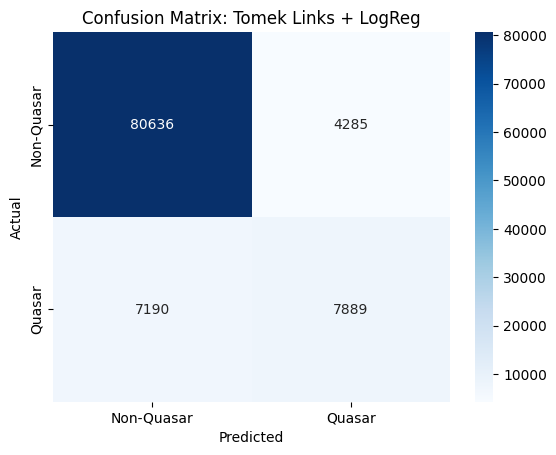

In [6]:
y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred, target_names=['Non-Quasar', 'Quasar']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Quasar', 'Quasar'], yticklabels=['Non-Quasar', 'Quasar'])
plt.title('Confusion Matrix: Tomek Links + LogReg')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## 10. Save Model for UI Deployment
Save the trained model and scaler so they can be loaded by the Streamlit application.


In [7]:
os.makedirs('../../models', exist_ok=True)
joblib.dump(model, '../../models/member1_logreg.pkl')
joblib.dump(scaler, '../../models/scaler_m1.pkl')
print('Model and Scaler saved to models/ directory.')


Model and Scaler saved to models/ directory.


## 11. Theoretical Question
### How does undersampling (Tomek Links) affect the bias-variance tradeoff in imbalanced classification?

**Background:** Every ML model faces a bias-variance tradeoff:
- **Bias** = systematic error from wrong assumptions
- **Variance** = sensitivity to training data fluctuations

**What Tomek Links does:**
Tomek Links removes majority-class samples at the boundary. This removes ambiguous samples that cause inconsistent decision boundaries, reducing **variance**. However, by removing valid representations of the true data distribution, it may increase **bias** if the overlap is intrinsic to the physics of photometry.
